# Recomendación basada en embeddings semánticos

Este notebook retoma el problema después del baseline TF-IDF. Con el dataset ruidoso, la tarea deja de ser solo clasificar una etiqueta y pasa a recuperar publicaciones cercanas a un perfil de interés. Para ello se adopta como modelo principal `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`, que permite representar mejor consultas en español y señales mezcladas entre categorías.


In [21]:
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

try:
    from sentence_transformers import SentenceTransformer
except ImportError as exc:
    raise ImportError("Falta instalar sentence-transformers. Ejecuta: %pip install -q sentence-transformers") from exc

DATA_PATH = Path("data/posts.csv")
REQUIRED_COLUMNS = ["id", "descripcion", "hashtags", "categoria"]
OPTIONAL_COLUMNS = [
    "categoria_generadora", "categoria_secundaria", "es_ambiguo", "tipo_post",
    "nivel_ruido", "etiqueta_ruidosa", "entidades",
]
MODELS_DIR = Path("models")
ARTIFACTS_DIR = Path("artifacts")
EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
EMBEDDING_MODEL_DIR = MODELS_DIR / "modelo_embeddings"
LEGACY_EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
LEGACY_EMBEDDING_MODEL_DIR = MODELS_DIR / "modelo_all_minilm_l6_v2"
EMBEDDING_METADATA_PATH = MODELS_DIR / "clasificador_embeddings.joblib"
EMBEDDINGS_ARTIFACT_PATH = ARTIFACTS_DIR / "embeddings_posts.joblib"
TOP_K = 10
COMPARISON_TOP_K = 5
INTERESES_USUARIO = [
    "vacaciones con música y playa",
    "viaje en coche por la costa",
    "probar comida local durante una escapada",
]
CATEGORIAS_RELEVANTES = {"playa", "viajes", "musica", "coches", "cocina"}
CONSULTAS_COMPARATIVA_MODELOS = [
    "vacaciones con música y playa",
    "viaje en coche por la costa",
    "jugando al FIFA escuchando Anuel",
    "cocinando mientras veo fútbol",
]
CATEGORIAS_ESPERADAS_COMPARATIVA = {
    "vacaciones con música y playa": {"playa", "viajes", "musica"},
    "viaje en coche por la costa": {"viajes", "coches", "playa"},
    "jugando al FIFA escuchando Anuel": {"videojuegos", "musica"},
    "cocinando mientras veo fútbol": {"cocina", "deporte"},
}

pd.set_option("display.max_colwidth", 140)
plt.style.use("seaborn-v0_8-whitegrid")


## 1. Carga y preparación textual

Para embeddings se conserva más información natural que en TF-IDF. Se separan hashtags, se normalizan espacios y se mantiene el texto social con nombres propios, emojis y contexto. También se calcula `texto_limpio` para comparabilidad con el notebook supervisado.


In [22]:
df = pd.read_csv(DATA_PATH, encoding="utf-8")
missing_columns = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
if missing_columns:
    raise ValueError(f"Faltan columnas obligatorias: {missing_columns}")

available_optional_columns = [column for column in OPTIONAL_COLUMNS if column in df.columns]
df = df[REQUIRED_COLUMNS + available_optional_columns].copy()

df["texto_original"] = (
    df["descripcion"].fillna("").astype(str).str.strip()
    + " "
    + df["hashtags"].fillna("").astype(str).str.replace("#", " #", regex=False).str.strip()
).str.replace(r"\s+", " ", regex=True).str.strip()

def preprocesar_texto(texto: str) -> str:
    texto = str(texto).lower().replace("#", " ")
    texto = re.sub(r"[^a-záéíóúüñ0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def preparar_texto_embedding(texto: str) -> str:
    texto = str(texto).replace("#", " ")
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


df["texto_limpio"] = df["texto_original"].apply(preprocesar_texto)
df["texto_embedding"] = df["texto_original"].apply(preparar_texto_embedding)
df_modelo = df[df["texto_embedding"].str.len() > 0].copy().reset_index(drop=True)

print(f"Archivo cargado desde: {DATA_PATH}")
print(f"Registros originales: {len(df)}")
print(f"Registros con texto útil: {len(df_modelo)}")
print(f"Registros excluidos por texto vacío: {len(df) - len(df_modelo)}")
display(df_modelo[["descripcion", "hashtags", "categoria", "texto_embedding"]].head(8))


Archivo cargado desde: data\posts.csv
Registros originales: 11000
Registros con texto útil: 10873
Registros excluidos por texto vacío: 127


,descripcion,hashtags,categoria,texto_embedding
0,plan improvisado: despues del gym cayo MasterChef porque el cuerpo lo pidio random pero necesario,#cocina #partido,deporte,plan improvisado: despues del gym cayo MasterChef porque el cuerpo lo pidio random pero necesario cocina partido
1,mini update: vuelo temprano con cafe dudoso sin filtros y con prisa 🎸,#gymbro #escapada #top,viajes,mini update: vuelo temprano con cafe dudoso sin filtros y con prisa 🎸 gymbro escapada top
2,vuelo temprano con cafe dudoso en Londres con camara,#Travel,viajes,vuelo temprano con cafe dudoso en Londres con camara Travel
3,"vibe de hoy: baño rapido antes de comer, que locura jajaja",#Random#Verano,playa,"vibe de hoy: baño rapido antes de comer, que locura jajaja Random Verano"
4,"vibe de hoy: brisa salada y cero prisa, ns q decir jaja",#sol,playa,"vibe de hoy: brisa salada y cero prisa, ns q decir jaja sol"
5,ebuFrEHS2JpDzfOvz1dOOdTXglHilC2e,#Aesthetic,musica,ebuFrEHS2JpDzfOvz1dOOdTXglHilC2e Aesthetic
6,"vacaciones con musica, playa y maleta medio rota en cadiz, despues de una semana eterna god",#Viajes,viajes,"vacaciones con musica, playa y maleta medio rota en cadiz, despues de una semana eterna god Viajes"
7,ruta corta por carreteras secundarias en Tokio con peaje,NaN,coches,ruta corta por carreteras secundarias en Tokio con peaje


In [23]:
if {"es_ambiguo", "categoria_secundaria"}.issubset(df_modelo.columns):
    print("Ejemplos ambiguos del dataset:")
    display(
        df_modelo[df_modelo["es_ambiguo"]]
        [["descripcion", "hashtags", "categoria", "categoria_secundaria", "nivel_ruido"]]
        .sample(10, random_state=42)
    )

    pares_ambiguos = (
        df_modelo[df_modelo["es_ambiguo"]]
        .groupby(["categoria", "categoria_secundaria"])
        .size()
        .reset_index(name="n_posts")
        .sort_values("n_posts", ascending=False)
    )
    print("Pares de categorías que más se solapan:")
    display(pares_ambiguos.head(15))


Ejemplos ambiguos del dataset:


,descripcion,hashtags,categoria,categoria_secundaria,nivel_ruido
2947,"domingo raro y viaje corto con el perro, maleta y demasiadas bolsas, sin planear demasiado god",#Vibes,animales,viajes,medio
7698,"JAJA hoy tocaba hotel que acepta mascotas y paseo eterno por gran canaria, con el movil sin bateria jajaja",#Paseo,animales,viajes,bajo
3725,domingo raro y stream de fifa con playlist de aitana y chat imposible top,NaN,musica,videojuegos,medio
10056,"domingo raro y taper de arroz, entreno tarde y cero glamour",NaN,deporte,cocina,bajo
2636,"nadie me preparo para mercado local, cafe raro y plato de MasterChef que salvo el dia random pero necesario ✈️",#Destino #Cena #Foodie,cocina,viajes,medio
6906,mini update: chiringuito lleno pero la y bueno,#verano #spotify,playa,musica,medio
8007,si esto no es felicidad entonces nada modo carrera en valorant mientras suena spotify de fondo. no encaja perfecto en una sola categoria...,#Planazo #GTA #Urbano,musica,videojuegos,alto
5008,no se como explicar esto pero perdido por soria siguiendo una cancion de bad bunny random pero necesario,#festival #aventura #live #roadtrip,musica,viajes,alto
8935,"despues de mil vueltas, zapatillas en el maletero y plan de ultima hora muy de hoy se tenia que decir",#futbol #partido #carlife,coches,deporte,bajo
8325,"mini update: despues del gym cayo tcaos porque el cuerpo lo pidio. no encaja perfecto en una sola categoria, porque mezcla deporte, coci...",#sabor,deporte,cocina,medio


Pares de categorías que más se solapan:


,categoria,categoria_secundaria,n_posts
39,videojuegos,musica,327
29,playa,viajes,320
9,coches,viajes,283
13,cocina,viajes,272
27,playa,musica,235
35,viajes,playa,231
32,viajes,cocina,224
11,cocina,deporte,216
24,musica,videojuegos,211
7,coches,deporte,210


## 2. Generación y persistencia de embeddings

El flujo principal del proyecto se apoya desde este punto en `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`. El modelo se carga desde `models/modelo_embeddings` si ya existe. Si no existe, se descarga una vez y se guarda localmente. Para la comparativa breve del final, el notebook también intenta reutilizar el modelo anterior `all-MiniLM-L6-v2` y, si no está persistido todavía, lo descarga y lo deja guardado en `models/modelo_all_minilm_l6_v2`.


In [24]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


def cargar_modelo_sentence_transformer(model_dir, model_name, require_local_only=False):
    if model_dir.exists():
        modelo = SentenceTransformer(str(model_dir), local_files_only=True)
        origen = f"modelo local persistido en {model_dir}"
        return modelo, origen

    if require_local_only:
        raise FileNotFoundError(
            f"No se encontró el modelo local {model_name} en {model_dir}. "
            "Para la comparativa, deja disponible ese directorio o vuelve a persistir el modelo."
        )

    modelo = SentenceTransformer(model_name)
    modelo.save(str(model_dir))
    origen = f"modelo descargado desde {model_name}"
    return modelo, origen


modelo_embeddings, origen_modelo_embeddings = cargar_modelo_sentence_transformer(
    EMBEDDING_MODEL_DIR,
    EMBEDDING_MODEL_NAME,
)

embeddings_posts = modelo_embeddings.encode(
    df_modelo["texto_embedding"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

post_columns = [
    column for column in [
        "id", "descripcion", "hashtags", "categoria", "categoria_generadora",
        "categoria_secundaria", "es_ambiguo", "tipo_post", "nivel_ruido",
        "etiqueta_ruidosa", "entidades", "texto_original", "texto_limpio", "texto_embedding",
    ] if column in df_modelo.columns
]

artefacto_embeddings = {
    "embeddings": embeddings_posts.astype(np.float32),
    "posts": df_modelo[post_columns].copy(),
    "embedding_model_name": EMBEDDING_MODEL_NAME,
    "embedding_model_dir": str(EMBEDDING_MODEL_DIR),
    "text_column": "texto_embedding",
    "data_path": str(DATA_PATH),
    "source_dataset_rows": int(len(df)),
    "source_model_rows": int(len(df_modelo)),
}

metadata_embeddings = {
    "embedding_model_name": EMBEDDING_MODEL_NAME,
    "embedding_model_dir": str(EMBEDDING_MODEL_DIR),
    "embeddings_artifact_path": str(EMBEDDINGS_ARTIFACT_PATH),
    "text_column": "texto_embedding",
    "data_path": str(DATA_PATH),
    "source_dataset_rows": int(len(df)),
    "source_model_rows": int(len(df_modelo)),
}

joblib.dump(artefacto_embeddings, EMBEDDINGS_ARTIFACT_PATH)
joblib.dump(metadata_embeddings, EMBEDDING_METADATA_PATH)

print(f"Modelo activo de embeddings: {EMBEDDING_MODEL_NAME}")
print(f"Origen del modelo: {origen_modelo_embeddings}")
print(f"Directorio local activo: {EMBEDDING_MODEL_DIR}")
print(f"Matriz de embeddings: {embeddings_posts.shape[0]} posts x {embeddings_posts.shape[1]} dimensiones")
print(f"Artefacto guardado en: {EMBEDDINGS_ARTIFACT_PATH}")


Batches: 100%|██████████| 170/170 [00:10<00:00, 15.96it/s]


Modelo activo de embeddings: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Origen del modelo: modelo local persistido en models\modelo_embeddings
Directorio local activo: models\modelo_embeddings
Matriz de embeddings: 10873 posts x 384 dimensiones
Artefacto guardado en: artifacts\embeddings_posts.joblib


## 3. Perfil vectorial y similitud coseno

El perfil de usuario se construye con frases naturales, no solo con nombres de categorías. Esto tensiona el sistema de forma más realista: una misma preferencia puede conectar playa, viajes, música, coches o comida según el contenido textual.


In [25]:
embeddings_intereses = modelo_embeddings.encode(
    INTERESES_USUARIO,
    show_progress_bar=False,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

perfil_usuario = embeddings_intereses.mean(axis=0, keepdims=True)
perfil_usuario = perfil_usuario / np.linalg.norm(perfil_usuario, axis=1, keepdims=True)

similitudes = cosine_similarity(perfil_usuario, embeddings_posts).ravel()
recomendaciones = df_modelo.copy()
recomendaciones["score_similitud"] = similitudes

top_k_posts = recomendaciones.sort_values("score_similitud", ascending=False).head(TOP_K).copy()
top_k_posts["score_similitud"] = top_k_posts["score_similitud"].round(4)

print(f"Intereses del usuario: {INTERESES_USUARIO}")
display(top_k_posts[[
    column for column in [
        "score_similitud", "categoria", "categoria_secundaria", "es_ambiguo",
        "nivel_ruido", "descripcion", "hashtags",
    ] if column in top_k_posts.columns
]])


Intereses del usuario: ['vacaciones con música y playa', 'viaje en coche por la costa', 'probar comida local durante una escapada']


,score_similitud,categoria,categoria_secundaria,es_ambiguo,nivel_ruido,descripcion,hashtags
5824,0.7962,playa,viajes,True,medio,"plan improvisado: vacaciones con musica, playa y maleta medio rota en granada, sin filtros y con prisa top",#Atardecer#Escapada
5640,0.7958,viajes,playa,True,medio,"literalmente vacaciones con musica, playa y maleta medio rota en Toio random pero necesario 🍣",#Turismo #Relax #Travel
802,0.7942,playa,viajes,True,bajo,"literalmente vacaciones con musica, playa y maleta medio rota en Cadiz, con gente buena asi si",#cafe #mar
126,0.7884,playa,viajes,True,alto,"literal literalmente vacaciones con musica, playa y maleta medio rota en ourense muy de hoy ⚽",#relax #atardecer #cafe #sinfiltros
6,0.7857,viajes,playa,True,medio,"vacaciones con musica, playa y maleta medio rota en cadiz, despues de una semana eterna god",#Viajes
7125,0.7836,playa,NaN,False,bajo,Formentera: paseo por la costa y god,#calas
4702,0.7808,coches,viajes,True,bajo,vibe de hoy: viaje en coche por la costa top,#Ruta #Turismo
650,0.7803,viajes,playa,True,bajo,"vacaciones con musica, playa y maleta medio rota en Tarragona, despues de una semana eterna random pero necesario",#Verano
8667,0.7789,playa,viajes,True,medio,"despues de mil vueltas, vacaciones con musica, playa y maleta medio rota JAJA",#life
3886,0.7778,viajes,playa,True,alto,"vibe de hoy: vacaciones con musica, playa y maleta medio rota en valencia y bueno",#Oferta


## 4. Evaluación básica del ranking

`Precision@K` se interpreta aquí como una medida aproximada de alineación con las categorías esperadas para el perfil simulado. Se añade diversidad categorial y proporción de posts ambiguos para detectar si el ranking queda sobreconcentrado o si recupera casos mixtos.


In [26]:
def precision_at_k(recomendaciones_df, categorias_relevantes):
    return recomendaciones_df["categoria"].isin(categorias_relevantes).mean()


def diversidad_at_k(recomendaciones_df):
    return recomendaciones_df["categoria"].nunique()


def ambiguedad_at_k(recomendaciones_df):
    if "es_ambiguo" not in recomendaciones_df.columns:
        return np.nan
    return recomendaciones_df["es_ambiguo"].mean()


resultados_precision = []
for k in [3, 5, 10]:
    top_k_eval = recomendaciones.sort_values("score_similitud", ascending=False).head(k).copy()
    resultados_precision.append(
        {
            "k": k,
            "precision_at_k": round(precision_at_k(top_k_eval, CATEGORIAS_RELEVANTES), 4),
            "diversidad_at_k": diversidad_at_k(top_k_eval),
            "ambiguedad_at_k": round(ambiguedad_at_k(top_k_eval), 4),
            "score_medio": round(top_k_eval["score_similitud"].mean(), 4),
            "categorias_top_k": " | ".join(top_k_eval["categoria"].tolist()),
        }
    )

df_precision = pd.DataFrame(resultados_precision)
display(df_precision)


,k,precision_at_k,diversidad_at_k,ambiguedad_at_k,score_medio,categorias_top_k
0,3,1.0,2,1.0,0.7954,playa | viajes | playa
1,5,1.0,2,1.0,0.7921,playa | viajes | playa | playa | viajes
2,10,1.0,3,0.9,0.7862,playa | viajes | playa | playa | viajes | playa | coches | viajes | playa | viajes


## 5. Consultas ambiguas

Una ventaja de los embeddings es que se pueden consultar frases mixtas sin entrenar un clasificador nuevo. Esto permite mostrar relaciones semánticas que TF-IDF tiende a convertir en competición entre palabras.


In [27]:
consultas = [
    "jugando al FIFA escuchando Anuel",
    "viaje en coche por la costa",
    "cocinando mientras veo fútbol",
    "vacaciones con música y playa"
]

for consulta in consultas:
    embedding_consulta = modelo_embeddings.encode(
        [consulta],
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    scores = cosine_similarity(embedding_consulta, embeddings_posts).ravel()
    vecinos = df_modelo.copy()
    vecinos["score"] = scores
    vecinos = vecinos.sort_values("score", ascending=False).head(5)
    print("=" * 100)
    print(f"Consulta: {consulta}")
    display(vecinos[[
        column for column in [
            "score", "categoria", "categoria_secundaria", "es_ambiguo", "descripcion", "hashtags",
        ] if column in vecinos.columns
    ]])


Consulta: jugando al FIFA escuchando Anuel


,score,categoria,categoria_secundaria,es_ambiguo,descripcion,hashtags
1188,0.823502,musica,videojuegos,True,"domingo raro y jugando al FIFA escuchando Anuel hasta que se fue el lag, mientras cae la tarde god",#urbano
6868,0.773889,videojuegos,musica,True,"literalmente modo carrera en FIFA mientras suena Anuel de fondo, mientras cae la tarde que locura modo chill 🍣",#planazo #urbano #twitch
3824,0.769014,musica,videojuegos,True,en bucle nadie me preparo para stream de FIFA con playlist de Anuel y chat imposible muy de hoy,#Vibes #GG #Temazo
4769,0.765736,videojuegos,musica,True,"en bucle si esto no es felicidad entonces nada jugando al FIFA escuchando Anuel hasta que se fue el lag, porque a veces sale bien sin pe...",NaN
1891,0.757404,videojuegos,musica,True,"vibe de hoy: jugando al FIFA escuchando Quevedo hasta que se fue el lag, entre risas y cero cobertura que locura 🧳",NaN


Consulta: viaje en coche por la costa


,score,categoria,categoria_secundaria,es_ambiguo,descripcion,hashtags
10347,0.836550,viajes,coches,True,me desperte pensando en esto: viaje en coche por la costa ✨,#Escapada
1771,0.823465,coches,coches,True,mini update: viaje en coche por la costa asi si,#Destino
10114,0.821530,viajes,playa,True,"despues de mil vueltas, caminata eterna por el centro, no pido mas; tambien paseo por la costa",#Mar #Verano #Travel #RoadTrip
3810,0.801798,coches,viajes,True,plan improvisado: viaje en coche por la costa top!!!,#Travel #Drive #Chill
8823,0.793296,playa,NaN,False,paseo por la costa en...,NaN


Consulta: cocinando mientras veo fútbol


,score,categoria,categoria_secundaria,es_ambiguo,descripcion,hashtags
4757,0.747666,cocina,deporte,True,me renta literalmente...,#futbol #hoy #cocina
10865,0.669463,deporte,NaN,False,vibe de hoy: comida sencilla despues del gimnasio con gente buena,#Futbol #Entreno
56,0.652298,deporte,cocina,True,nadie me preparo para partido del nike y cena improvisada en casa muy de hoy me renta 🎮,#Foodie #Running #Futbol
6503,0.641566,deporte,NaN,False,mini update: comida sencilla despues del gimnasio despues de una semana eterna,#Top #Futbol
7100,0.633463,deporte,cocina,True,vibe de hoy: partido del Adidas y cena...,#futbol #partido #cocina


Consulta: vacaciones con música y playa


,score,categoria,categoria_secundaria,es_ambiguo,descripcion,hashtags
3886,0.870107,viajes,playa,True,"vibe de hoy: vacaciones con musica, playa y maleta medio rota en valencia y bueno",#Oferta
6554,0.846713,playa,viajes,True,literalmente vacaciones con musica bro esto esta increible,#viajes #travel #mar #verano
7495,0.845234,viajes,playa,True,"plan improvisado: vacaciones con musica, playa y maleta medio JAJA",#Travel #Mood
6,0.833529,viajes,playa,True,"vacaciones con musica, playa y maleta medio rota en cadiz, despues de una semana eterna god",#Viajes
2327,0.831791,playa,viajes,True,"literalmente vacaciones con musica, playa y maleta medio rota en la rioja que locura",#sol #verano


## 6. Comparativa breve entre modelos de embeddings

Antes de cerrar el notebook, se contrasta el modelo multilinguaje elegido con el modelo anterior `all-MiniLM-L6-v2`. La comparación es pequeña y deliberadamente práctica: usa consultas en español o mixtas, calcula `Precision@5` sobre categorías esperadas y resume visualmente por qué el TFM pasa a apoyarse en el modelo multilingüe como opción principal.


Batches: 100%|██████████| 170/170 [00:11<00:00, 14.99it/s]


Modelo de comparación base: sentence-transformers/all-MiniLM-L6-v2
Origen modelo base: modelo descargado desde sentence-transformers/all-MiniLM-L6-v2
Modelo principal adoptado: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Origen modelo principal: modelo local persistido en models\modelo_embeddings


,consulta,categorias_esperadas,precision_at_5_all_minilm_l6_v2,precision_at_5_multilingue,mejora_precision_at_5,categoria_top_1_all_minilm_l6_v2,categoria_top_1_multilingue
0,vacaciones con música y playa,musica | playa | viajes,1.0,1.0,0.0,playa,viajes
1,viaje en coche por la costa,coches | playa | viajes,1.0,1.0,0.0,viajes,viajes
2,jugando al FIFA escuchando Anuel,musica | videojuegos,1.0,1.0,0.0,videojuegos,musica
3,cocinando mientras veo fútbol,cocina | deporte,0.8,1.0,0.2,cocina,cocina


,modelo,precision_at_5_media,score_top_1_medio
0,all-MiniLM-L6-v2,0.95,0.8142
1,paraphrase-multilingual-MiniLM-L12-v2,1.00,0.8195


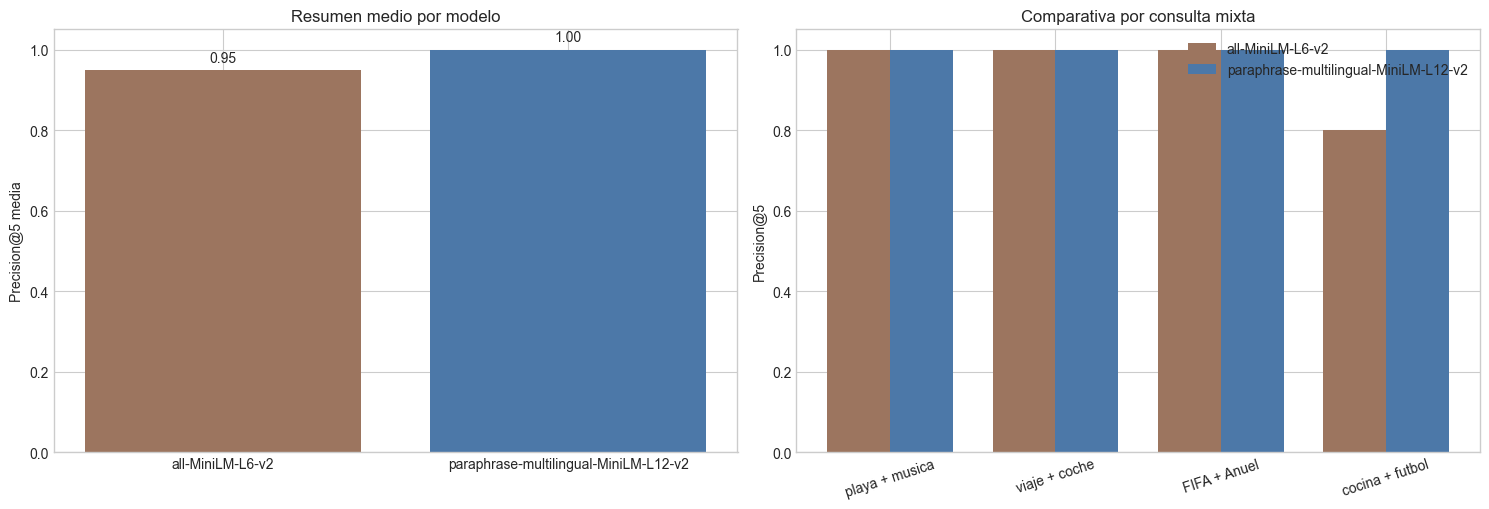

In [28]:
def evaluar_consultas_por_modelo(modelo, embeddings_corpus, nombre_modelo, top_k=COMPARISON_TOP_K):
    filas = []
    for consulta in CONSULTAS_COMPARATIVA_MODELOS:
        embedding_consulta = modelo.encode(
            [consulta],
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        scores = cosine_similarity(embedding_consulta, embeddings_corpus).ravel()
        ranking = df_modelo.copy()
        ranking["score"] = scores
        ranking = ranking.sort_values("score", ascending=False).head(top_k).copy()
        categorias_esperadas = CATEGORIAS_ESPERADAS_COMPARATIVA[consulta]
        filas.append(
            {
                "modelo": nombre_modelo,
                "consulta": consulta,
                "categorias_esperadas": " | ".join(sorted(categorias_esperadas)),
                "precision_at_5": round(float(precision_at_k(ranking, categorias_esperadas)), 4),
                "score_top_1": round(float(ranking.iloc[0]["score"]), 4),
                "categoria_top_1": ranking.iloc[0]["categoria"],
                "categorias_top_5": " | ".join(ranking["categoria"].tolist()),
            }
        )
    return pd.DataFrame(filas)


modelo_embeddings_legacy, origen_modelo_legacy = cargar_modelo_sentence_transformer(
    LEGACY_EMBEDDING_MODEL_DIR,
    LEGACY_EMBEDDING_MODEL_NAME,
)

embeddings_posts_legacy = modelo_embeddings_legacy.encode(
    df_modelo["texto_embedding"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

resultados_legacy_df = evaluar_consultas_por_modelo(
    modelo_embeddings_legacy,
    embeddings_posts_legacy,
    "all-MiniLM-L6-v2",
)
resultados_multilingue_df = evaluar_consultas_por_modelo(
    modelo_embeddings,
    embeddings_posts,
    "paraphrase-multilingual-MiniLM-L12-v2",
)

comparativa_modelos_embeddings_df = resultados_legacy_df.merge(
    resultados_multilingue_df,
    on=["consulta", "categorias_esperadas"],
    suffixes=("_all_minilm_l6_v2", "_multilingue"),
)
comparativa_modelos_embeddings_df["mejora_precision_at_5"] = (
    comparativa_modelos_embeddings_df["precision_at_5_multilingue"]
    - comparativa_modelos_embeddings_df["precision_at_5_all_minilm_l6_v2"]
).round(4)

print(f"Modelo de comparación base: {LEGACY_EMBEDDING_MODEL_NAME}")
print(f"Origen modelo base: {origen_modelo_legacy}")
print(f"Modelo principal adoptado: {EMBEDDING_MODEL_NAME}")
print(f"Origen modelo principal: {origen_modelo_embeddings}")

display(comparativa_modelos_embeddings_df[[
    "consulta",
    "categorias_esperadas",
    "precision_at_5_all_minilm_l6_v2",
    "precision_at_5_multilingue",
    "mejora_precision_at_5",
    "categoria_top_1_all_minilm_l6_v2",
    "categoria_top_1_multilingue",
]])

resumen_modelos_embeddings_df = pd.DataFrame(
    [
        {
            "modelo": "all-MiniLM-L6-v2",
            "precision_at_5_media": resultados_legacy_df["precision_at_5"].mean(),
            "score_top_1_medio": resultados_legacy_df["score_top_1"].mean(),
        },
        {
            "modelo": "paraphrase-multilingual-MiniLM-L12-v2",
            "precision_at_5_media": resultados_multilingue_df["precision_at_5"].mean(),
            "score_top_1_medio": resultados_multilingue_df["score_top_1"].mean(),
        },
    ]
)
resumen_modelos_embeddings_df[["precision_at_5_media", "score_top_1_medio"]] = resumen_modelos_embeddings_df[[
    "precision_at_5_media",
    "score_top_1_medio",
]].round(4)
display(resumen_modelos_embeddings_df)

orden_consultas = CONSULTAS_COMPARATIVA_MODELOS
legacy_scores = resultados_legacy_df.set_index("consulta").loc[orden_consultas, "precision_at_5"].to_numpy()
multi_scores = resultados_multilingue_df.set_index("consulta").loc[orden_consultas, "precision_at_5"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
colores = ["#9C755F", "#4C78A8"]

axes[0].bar(
    resumen_modelos_embeddings_df["modelo"],
    resumen_modelos_embeddings_df["precision_at_5_media"],
    color=colores,
)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Precision@5 media")
axes[0].set_title("Resumen medio por modelo")
for idx, valor in enumerate(resumen_modelos_embeddings_df["precision_at_5_media"]):
    axes[0].text(idx, valor + 0.02, f"{valor:.2f}", ha="center")

x = np.arange(len(orden_consultas))
width = 0.38
axes[1].bar(x - width / 2, legacy_scores, width=width, label="all-MiniLM-L6-v2", color=colores[0])
axes[1].bar(x + width / 2, multi_scores, width=width, label="paraphrase-multilingual-MiniLM-L12-v2", color=colores[1])
axes[1].set_xticks(x)
axes[1].set_xticklabels([
    "playa + musica",
    "viaje + coche",
    "FIFA + Anuel",
    "cocina + futbol",
], rotation=18)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Precision@5")
axes[1].set_title("Comparativa por consulta mixta")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Lectura técnica

El uso de embeddings semánticos permite representar publicaciones mediante significado contextual y no únicamente mediante frecuencia de palabras. Esto mejora considerablemente la capacidad del sistema para manejar frases ambiguas, vocabulario no visto y relaciones semánticas entre categorías.

Frente al enfoque basado en TF-IDF, el sistema de embeddings consigue recuperar publicaciones relacionadas aunque no compartan exactamente las mismas palabras, ofreciendo una representación más flexible y natural del contenido. En este TFM, además, el cambio hacia `paraphrase-multilingual-MiniLM-L12-v2` refuerza esa lectura porque el corpus y las consultas están en español y combinan señales sociales, nombres propios y categorías mixtas.

La comparativa breve frente a `all-MiniLM-L6-v2` no pretende ser un benchmark exhaustivo, pero sí deja una evidencia útil: cuando las consultas mezclan intereses o están formuladas de forma natural en español, el modelo multilingüe ofrece una alineación más coherente con las categorías esperadas.

Estas observaciones motivan el notebook 03, centrado en comparar directamente el comportamiento del modelo supervisado clásico frente al sistema basado en embeddings. El objetivo de dicha comparativa es analizar diferencias en:

capacidad de generalización,
manejo de ambigüedad,
dependencia del vocabulario,
recuperación semántica,
diversidad de resultados,
y comportamiento ante publicaciones mixtas o ruidosas.
